# SSH2.0 ↔ GDPa1 contamination & overlap audit

**Why this notebook exists.** Our plan is to use SSH2.0 (an SVM trained on the Jain et al. 2017
panel) as a *weak labeler* to pretrain a hydrophobicity (HIC) oracle, then fine-tune on GDPa1.
That only makes sense if we can evaluate the oracle on antibodies SSH2.0 has **never seen** —
otherwise any measured "improvement" is just leakage.

This notebook quantifies the overlap between SSH2.0's training set and GDPa1, at the **CV-fold
level**, so we can decide whether a leakage-free evaluation is even possible with the provided
splits. It answers four questions:

1. How many of SSH2.0's training antibodies are inside GDPa1? (name + sequence matching)
2. After flagging them, **is any GDPa1 CV fold clean** (contains zero SSH2.0 antibodies)?
3. Do the **HIC labels agree** for the shared antibodies? (label QC across the two sources)
4. Is the SSH2.0 subset's **HIC distribution representative** of full GDPa1?

The notebook is top-to-bottom runnable. Run it from the repo (it locates `data/` automatically).

## Section 0 — Setup

In [1]:
from pathlib import Path
import re
import difflib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr, pearsonr

sns.set_theme(style="whitegrid", context="notebook")

# Consistent colors across all plots
C_GDPA1 = "#4C72B0"  # full GDPa1 (blue)
C_SSH2  = "#DD8452"  # SSH2.0 / contaminated subset (orange)
C_CLEAN = "#55A868"  # clean subset (green)

# A VH+VL identity (approximate) at/above this counts as the "same" antibody (near-duplicate).
NEAR_DUP_THRESHOLD = 0.95


def find_data_dir() -> Path:
    '''Locate the repo's data/ folder by walking up from the current directory.'''
    for base in [Path.cwd(), *Path.cwd().parents]:
        if (base / "data" / "GDPa1_v1.2_20250814.csv").exists():
            return base / "data"
    raise FileNotFoundError("Could not find data/ — run this notebook from inside the repo.")


DATA = find_data_dir()
print("data dir:", DATA)

Matplotlib is building the font cache; this may take a moment.


data dir: /Users/shyamchandra/Library/CloudStorage/GoogleDrive-shyam_chandra@hms.harvard.edu/.shortcut-targets-by-id/1Ve87J7W_cY3XfNb6VE9B8R6HLMdhaXwE/antibody/antibodydevelopability/data


## Section 1 — Load the two datasets

In [2]:
gdpa1 = pd.read_csv(DATA / "GDPa1_v1.2_20250814.csv")
ssh2  = pd.read_csv(DATA / "SSH2.0" / "jain_et_al_ssh2_training.csv")

print(f"GDPa1:               {gdpa1.shape[0]} antibodies x {gdpa1.shape[1]} columns")
print(f"SSH2.0 (Jain et al): {ssh2.shape[0]} antibodies x {ssh2.shape[1]} columns")

# Columns we rely on downstream.
FOLD_COLS = [
    "hierarchical_cluster_fold",
    "hierarchical_cluster_IgG_isotype_stratified_fold",
    "random_fold",
]
SSH2_HIC_COL = "HIC Retention Time (Min)a"   # SSH2.0/Jain's HIC measurement
assert "HIC" in gdpa1.columns, "GDPa1 HIC column missing"
assert SSH2_HIC_COL in ssh2.columns, "SSH2.0 HIC column missing"

GDPa1:               246 antibodies x 30 columns
SSH2.0 (Jain et al): 137 antibodies x 21 columns


## Section 2 — Matching helpers

We match SSH2.0 antibodies to GDPa1 two independent ways and take the union:

- **Name** — normalized INN drug name (`antibody_name` ↔ `Name`).
- **Sequence** — concatenated variable heavy + light domains (`vh/vl_protein_sequence` ↔ `VH`/`VL`),
  using an approximate identity to also catch near-duplicate sequence variants.

The identity is `difflib`'s ratio (no alignment dependency) — adequate for flagging
near-duplicates, not a substitute for a proper alignment.

In [3]:
def normalize_name(s) -> str:
    '''Lowercase, strip, and drop whitespace so INN names compare cleanly.'''
    return re.sub(r"\s+", "", str(s).strip().lower())


def vh_vl(vh, vl) -> str:
    '''Concatenate variable heavy + light domains into one uppercase string.'''
    return (str(vh).strip() + str(vl).strip()).upper()


def seq_identity(a: str, b: str) -> float:
    '''Approximate sequence identity in [0, 1] via difflib ratio.'''
    return difflib.SequenceMatcher(a=a, b=b).ratio()

## Section 3 — Match SSH2.0 antibodies into GDPa1

In [4]:
# Build match keys on both tables.
gdpa1["name_key"] = gdpa1["antibody_name"].map(normalize_name)
ssh2["name_key"]  = ssh2["Name"].map(normalize_name)
gdpa1["seq_key"]  = [vh_vl(h, l) for h, l in zip(gdpa1.vh_protein_sequence, gdpa1.vl_protein_sequence)]
ssh2["seq_key"]   = [vh_vl(h, l) for h, l in zip(ssh2.VH, ssh2.VL)]

# 1) exact name match
name_to_id = dict(zip(gdpa1.name_key, gdpa1.antibody_id))
ssh2["name_match_id"] = ssh2.name_key.map(name_to_id)

# 2) exact VH+VL match
seq_to_id = {}
for aid, s in zip(gdpa1.antibody_id, gdpa1.seq_key):
    seq_to_id.setdefault(s, aid)
ssh2["exact_seq_id"] = ssh2.seq_key.map(seq_to_id)

# 3) nearest VH+VL by identity (only needed where there is no exact sequence hit)
gd_pairs = list(zip(gdpa1.antibody_id, gdpa1.seq_key))

def nearest(seq: str):
    '''Return (best_gdpa1_id, best_identity) for a query VH+VL sequence.'''
    best_id, best_r = None, 0.0
    matcher = difflib.SequenceMatcher(b=seq)
    for aid, s in gd_pairs:
        matcher.set_seq1(s)
        if matcher.real_quick_ratio() <= best_r:   # cheap upper-bound prune
            continue
        r = matcher.ratio()
        if r > best_r:
            best_id, best_r = aid, r
    return best_id, best_r

nearest_id, nearest_identity = [], []
for exact_id, seq in zip(ssh2.exact_seq_id, ssh2.seq_key):
    if pd.notna(exact_id):
        nearest_id.append(exact_id); nearest_identity.append(1.0)
    else:
        bid, br = nearest(seq); nearest_id.append(bid); nearest_identity.append(br)
ssh2["nearest_id"] = nearest_id
ssh2["nearest_identity"] = nearest_identity

print(f"Name matches:           {ssh2.name_match_id.notna().sum()}/{len(ssh2)}")
print(f"Exact VH+VL matches:    {ssh2.exact_seq_id.notna().sum()}/{len(ssh2)}")
print(f"Near matches (>={NEAR_DUP_THRESHOLD}):  {(ssh2.nearest_identity >= NEAR_DUP_THRESHOLD).sum()}/{len(ssh2)}")
print(f"NOT found in GDPa1:     {(ssh2.nearest_identity < NEAR_DUP_THRESHOLD).sum()}/{len(ssh2)}")

Name matches:           135/137
Exact VH+VL matches:    135/137
Near matches (>=0.95):  135/137
NOT found in GDPa1:     2/137


### How cleanly does each SSH2.0 antibody match GDPa1?

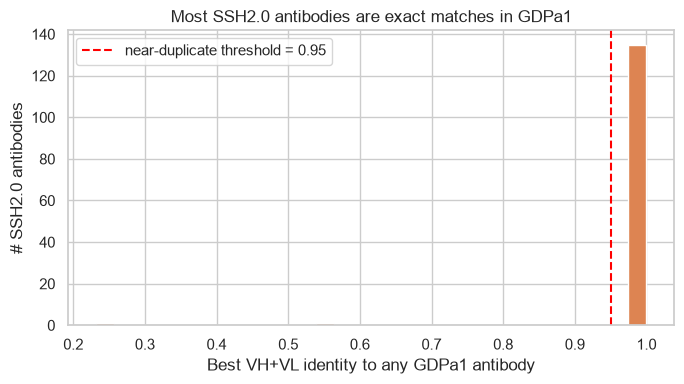

SSH2.0 antibodies NOT confidently found in GDPa1:
       Name nearest_id  nearest_identity
canakinumab  GDPa1-078          0.231626
 drozitumab  GDPa1-124          0.547046


In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(ssh2.nearest_identity, bins=30, color=C_SSH2, edgecolor="white")
ax.axvline(NEAR_DUP_THRESHOLD, color="red", ls="--",
           label=f"near-duplicate threshold = {NEAR_DUP_THRESHOLD}")
ax.set(xlabel="Best VH+VL identity to any GDPa1 antibody",
       ylabel="# SSH2.0 antibodies",
       title="Most SSH2.0 antibodies are exact matches in GDPa1")
ax.legend()
plt.tight_layout(); plt.show()

not_found = ssh2.loc[ssh2.nearest_identity < NEAR_DUP_THRESHOLD,
                     ["Name", "nearest_id", "nearest_identity"]]
print("SSH2.0 antibodies NOT confidently found in GDPa1:")
print(not_found.to_string(index=False) if len(not_found) else "  (none)")

## Section 4 — Flag contamination on GDPa1

In [6]:
# A GDPa1 antibody is "contaminated" if SSH2.0 was trained on it (matched by name or by sequence).
contaminated = (
    set(ssh2.name_match_id.dropna())
    | set(ssh2.loc[ssh2.nearest_identity >= NEAR_DUP_THRESHOLD, "nearest_id"].dropna())
)
gdpa1["ssh2_contaminated"] = gdpa1.antibody_id.isin(contaminated)

n_contam = int(gdpa1.ssh2_contaminated.sum())
print(f"Contaminated GDPa1 antibodies: {n_contam}/{len(gdpa1)} ({100*n_contam/len(gdpa1):.0f}%)")
print(f"Clean GDPa1 antibodies:        {len(gdpa1) - n_contam}")

Contaminated GDPa1 antibodies: 135/246 (55%)
Clean GDPa1 antibodies:        111


## Section 5 — Contamination per CV fold

The key question: does **any** provided fold contain zero SSH2.0 antibodies? If not, the standard
cluster-CV splits cannot give us an SSH2.0-naive test fold.

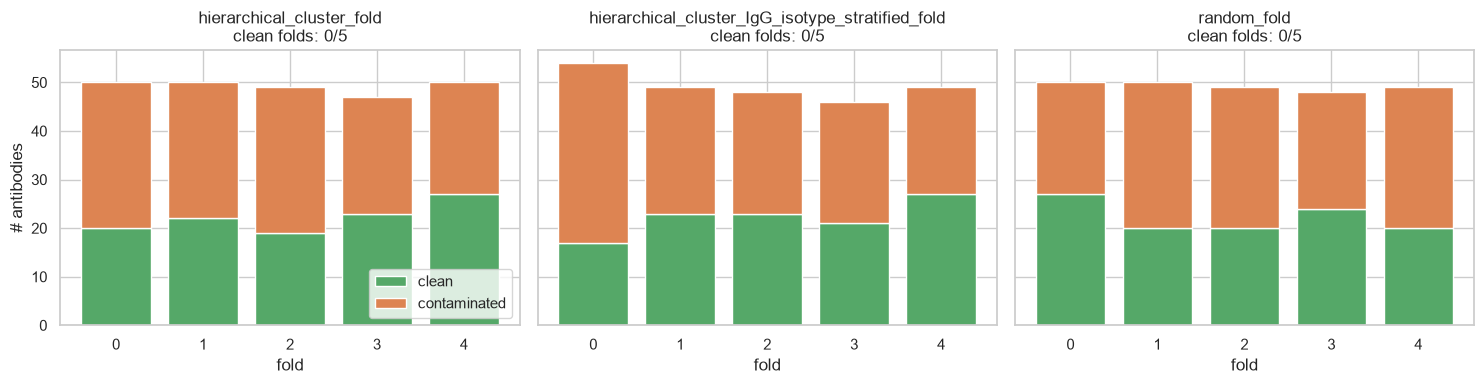


hierarchical_cluster_fold: clean folds = 0/5
                           contaminated  total  clean  contaminated_pct
hierarchical_cluster_fold                                              
0                                    30     50     20              60.0
1                                    28     50     22              56.0
2                                    30     49     19              61.0
3                                    24     47     23              51.0
4                                    23     50     27              46.0

hierarchical_cluster_IgG_isotype_stratified_fold: clean folds = 0/5
                                                  contaminated  total  clean  contaminated_pct
hierarchical_cluster_IgG_isotype_stratified_fold                                              
0                                                           37     54     17              69.0
1                                                           26     49     23              53.0
2

In [7]:
def fold_contamination(df: pd.DataFrame, fold_col: str) -> pd.DataFrame:
    t = df.groupby(fold_col)["ssh2_contaminated"].agg(contaminated="sum", total="count")
    t["clean"] = t.total - t.contaminated
    t["contaminated_pct"] = (100 * t.contaminated / t.total).round(0)
    return t

fig, axes = plt.subplots(1, len(FOLD_COLS), figsize=(15, 4), sharey=True)
for ax, col in zip(axes, FOLD_COLS):
    t = fold_contamination(gdpa1, col)
    n_clean_folds = int((t.contaminated == 0).sum())
    ax.bar(t.index.astype(str), t.clean, color=C_CLEAN, label="clean")
    ax.bar(t.index.astype(str), t.contaminated, bottom=t.clean, color=C_SSH2, label="contaminated")
    ax.set(title=f"{col}\nclean folds: {n_clean_folds}/{len(t)}", xlabel="fold")
axes[0].set_ylabel("# antibodies")
axes[0].legend(loc="lower right")
plt.tight_layout(); plt.show()

for col in FOLD_COLS:
    t = fold_contamination(gdpa1, col)
    print(f"\n{col}: clean folds = {int((t.contaminated == 0).sum())}/{len(t)}")
    print(t.to_string())

## Section 6 — HIC label QC for shared antibodies

For antibodies in both datasets, do the HIC measurements agree? GDPa1's `HIC` and SSH2.0/Jain's
`HIC Retention Time` may be different assays — we check both the scale and the rank agreement.

Matched pairs with both HIC values: 131
GDPa1 HIC         range [2.43, 4.50], mean 2.84
Jain HIC RetTime  range [8.47, 25.00], mean 10.36
Pearson r = 0.703   Spearman rho = 0.968   identical values: False


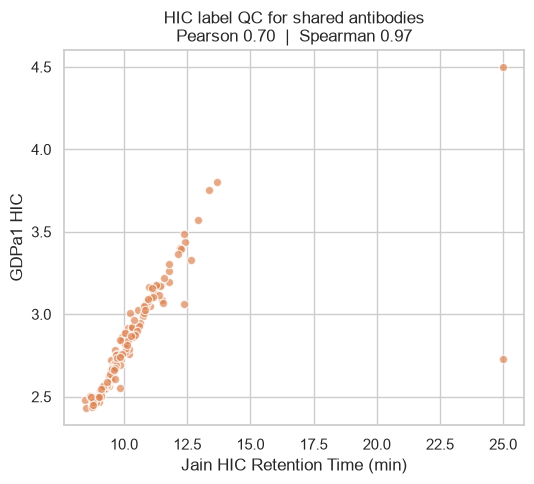

In [8]:
matched = ssh2[ssh2.nearest_identity >= NEAR_DUP_THRESHOLD].copy()
matched["gdpa1_HIC"] = matched.nearest_id.map(gdpa1.set_index("antibody_id")["HIC"])
qc = matched.dropna(subset=["gdpa1_HIC", SSH2_HIC_COL])

rho = spearmanr(qc.gdpa1_HIC, qc[SSH2_HIC_COL])[0]
r   = pearsonr(qc.gdpa1_HIC, qc[SSH2_HIC_COL])[0]

print(f"Matched pairs with both HIC values: {len(qc)}")
print(f"GDPa1 HIC         range [{qc.gdpa1_HIC.min():.2f}, {qc.gdpa1_HIC.max():.2f}], mean {qc.gdpa1_HIC.mean():.2f}")
print(f"Jain HIC RetTime  range [{qc[SSH2_HIC_COL].min():.2f}, {qc[SSH2_HIC_COL].max():.2f}], mean {qc[SSH2_HIC_COL].mean():.2f}")
print(f"Pearson r = {r:.3f}   Spearman rho = {rho:.3f}   identical values: {np.allclose(qc.gdpa1_HIC, qc[SSH2_HIC_COL])}")

fig, ax = plt.subplots(figsize=(5.5, 5))
ax.scatter(qc[SSH2_HIC_COL], qc.gdpa1_HIC, color=C_SSH2, alpha=0.7, edgecolor="white")
ax.set(xlabel="Jain HIC Retention Time (min)", ylabel="GDPa1 HIC",
       title=f"HIC label QC for shared antibodies\nPearson {r:.2f}  |  Spearman {rho:.2f}")
plt.tight_layout(); plt.show()

## Section 7 — HIC distribution: SSH2.0 subset vs full GDPa1

If the SSH2.0 subset covers a different HIC range than GDPa1, weak supervision may not transfer
across the whole range. We overlay the distributions (different colors).

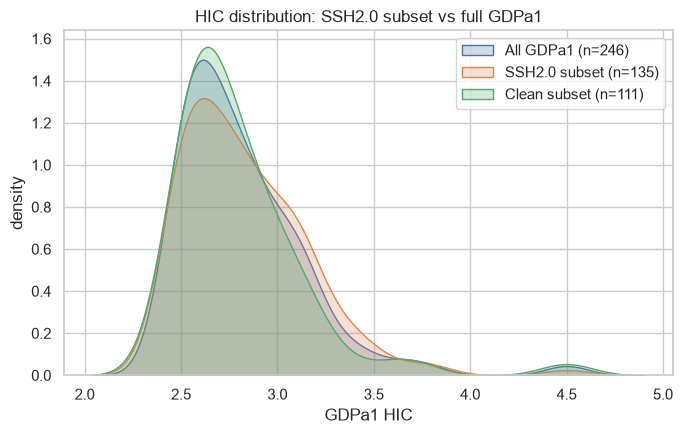

        group   n  HIC_mean  HIC_sd
    All GDPa1 246     2.821   0.338
SSH2.0 subset 135     2.837   0.330
 Clean subset 111     2.803   0.348


In [9]:
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.kdeplot(x=gdpa1.HIC, ax=ax, color=C_GDPA1, fill=True, alpha=0.25,
            label=f"All GDPa1 (n={len(gdpa1)})")
sns.kdeplot(x=gdpa1.loc[gdpa1.ssh2_contaminated, "HIC"], ax=ax, color=C_SSH2, fill=True, alpha=0.25,
            label=f"SSH2.0 subset (n={int(gdpa1.ssh2_contaminated.sum())})")
sns.kdeplot(x=gdpa1.loc[~gdpa1.ssh2_contaminated, "HIC"], ax=ax, color=C_CLEAN, fill=True, alpha=0.25,
            label=f"Clean subset (n={int((~gdpa1.ssh2_contaminated).sum())})")
ax.set(xlabel="GDPa1 HIC", ylabel="density",
       title="HIC distribution: SSH2.0 subset vs full GDPa1")
ax.legend()
plt.tight_layout(); plt.show()

summary = pd.DataFrame({
    "group": ["All GDPa1", "SSH2.0 subset", "Clean subset"],
    "n": [len(gdpa1), int(gdpa1.ssh2_contaminated.sum()), int((~gdpa1.ssh2_contaminated).sum())],
    "HIC_mean": [gdpa1.HIC.mean(),
                 gdpa1.loc[gdpa1.ssh2_contaminated, "HIC"].mean(),
                 gdpa1.loc[~gdpa1.ssh2_contaminated, "HIC"].mean()],
    "HIC_sd": [gdpa1.HIC.std(),
               gdpa1.loc[gdpa1.ssh2_contaminated, "HIC"].std(),
               gdpa1.loc[~gdpa1.ssh2_contaminated, "HIC"].std()],
})
print(summary.round(3).to_string(index=False))

## Section 8 — Verdict

In [10]:
clean_by_fold = {c: int((fold_contamination(gdpa1, c).contaminated == 0).sum()) for c in FOLD_COLS}

print("VERDICT")
print("=" * 56)
print(f"SSH2.0 antibodies located in GDPa1: "
      f"{int((ssh2.nearest_identity >= NEAR_DUP_THRESHOLD).sum())}/{len(ssh2)}")
print(f"GDPa1 contaminated: {int(gdpa1.ssh2_contaminated.sum())}/{len(gdpa1)} "
      f"({100*gdpa1.ssh2_contaminated.mean():.0f}%)  |  "
      f"clean individuals: {int((~gdpa1.ssh2_contaminated).sum())}")
for col, n in clean_by_fold.items():
    print(f"clean folds in {col}: {n}/5")
print(f"HIC label agreement (shared abs): Spearman {rho:.2f}, Pearson {r:.2f} (different scale)")

VERDICT
SSH2.0 antibodies located in GDPa1: 135/137
GDPa1 contaminated: 135/246 (55%)  |  clean individuals: 111
clean folds in hierarchical_cluster_fold: 0/5
clean folds in hierarchical_cluster_IgG_isotype_stratified_fold: 0/5
clean folds in random_fold: 0/5
HIC label agreement (shared abs): Spearman 0.97, Pearson 0.70 (different scale)


## Section 9 — What this means & path forward

**Findings**
- ~55% of GDPa1 is contaminated (SSH2.0 was trained on it), and **no provided CV fold is clean** —
  every fold contains SSH2.0 antibodies. The standard cluster/isotype splits therefore cannot
  give an SSH2.0-naive test fold.
- The ~111 clean individuals are scattered across all folds, so they share germline families with
  contaminated antibodies — individual-level cleanliness does not guarantee family-level cleanliness.
- GDPa1 HIC and Jain HIC are **rank-consistent (Spearman ≈ 0.97) but on different scales** —
  same underlying property, different assay readout. Any cross-source label use must be rank-based.
- The SSH2.0 subset's HIC distribution is representative of full GDPa1 (no target-range shift).

**Implications for the weak-supervision experiment** (to discuss before building the oracle):
1. **Individual-level holdout** — evaluate only on the ~111 clean individuals. Cheapest, but
   leaves family-level leakage (their germline families were seen by SSH2.0); weaker claim.
2. **Custom germline-family regrouping** — compute heavy/light V-gene families ourselves
   (deferred scope (b); needs ANARCI/IgBLAST) and search for genuinely clean families. Given the
   dispersion seen here, clean families may be few or none — worth checking before committing.
3. **Reframe the comparison** — lean on the data-efficiency curve and the L0-full vs L0-clean
   bracket rather than a single clean test fold; be explicit about residual leakage.

Next step: decide which path above to pursue for the HIC oracle evaluation.